In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('Cleaned dataset.csv')

In [4]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [5]:
df.columns


Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [6]:
# drop day, month and year
df.drop(['day', 'month', 'year'], axis=1, inplace=True)

In [7]:
df.sample(10)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
6,33,54,13,0.0,88.2,9.9,30.5,6.4,10.9,7.2,fire,0
24,31,64,15,0.0,86.7,14.2,63.8,5.7,18.3,8.4,fire,0
5,31,67,14,0.0,82.6,5.8,22.2,3.1,7.0,2.5,fire,0
152,28,58,18,2.2,63.7,3.2,8.5,1.2,3.3,0.5,not fire,1
80,35,68,19,0.0,88.3,25.9,130.6,8.8,34.7,16.8,fire,0
217,30,58,12,4.1,66.1,4.0,8.4,1.0,3.9,0.4,not fire,1
54,31,65,18,0.0,84.3,12.5,88.7,4.8,18.5,7.3,fire,0
23,32,66,17,0.0,85.9,11.2,55.8,5.6,14.9,7.5,fire,0
32,32,76,20,0.7,63.1,2.6,9.2,1.3,3.0,0.5,not fire,0
205,35,38,15,0.0,92.1,51.3,147.7,12.2,54.9,26.9,fire,1


In [8]:
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

In [9]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0, 1)

In [10]:
df.sample(10)
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [11]:
# Independent and dependent features

X = df.drop('FWI', axis=1)
y = df['FWI']

In [12]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [13]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [15]:
X_train.shape, X_test.shape

((194, 11), (49, 11))

In [16]:
# Feature selection based on correlation

X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.653725,-0.308149,-0.313112,0.690285,0.468911,0.372163,0.613138,0.446280,0.539642,0.258344
RH,-0.653725,1.000000,0.211645,0.239441,-0.649239,-0.401836,-0.220945,-0.714640,-0.346511,-0.454926,-0.408441
Ws,-0.308149,0.211645,1.000000,0.235922,-0.176596,0.004712,0.092866,-0.002300,0.037465,-0.075322,-0.202357
Rain,-0.313112,0.239441,0.235922,1.000000,-0.547864,-0.288538,-0.301110,-0.349903,-0.299179,-0.378585,-0.057382
FFMC,0.690285,-0.649239,-0.176596,-0.547864,1.000000,0.611978,0.519513,0.751819,0.598248,0.786012,0.254770
DMC,0.468911,-0.401836,0.004712,-0.288538,0.611978,1.000000,0.876122,0.679049,0.983891,0.606775,0.188980
DC,0.372163,-0.220945,0.092866,-0.301110,0.519513,0.876122,1.000000,0.512934,0.946181,0.538893,-0.083038
ISI,0.613138,-0.714640,-0.002300,-0.349903,0.751819,0.679049,0.512934,1.000000,0.637669,0.740072,0.291889
BUI,0.446280,-0.346511,0.037465,-0.299179,0.598248,0.983891,0.946181,0.637669,1.000000,0.602102,0.090326
Classes,0.539642,-0.454926,-0.075322,-0.378585,0.786012,0.606775,0.538893,0.740072,0.602102,1.000000,0.196276


<Axes: >

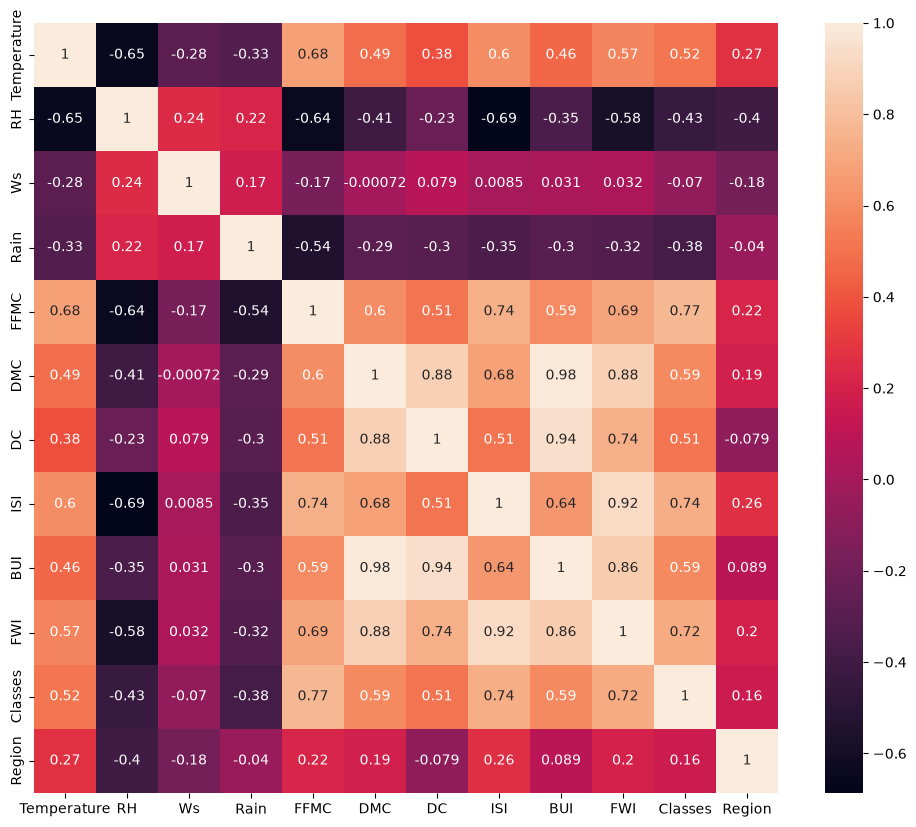

In [17]:
# check for multicollinearity

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot = True)

In [18]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [19]:
# threshold -- Domain Expertise

corr_features = correlation(X_train, 0.85)
corr_features

{'BUI', 'DC'}

In [20]:
## drop features when correlation is more than 0.85

X_train.drop(corr_features, axis=1, inplace=True)
X_test.drop(corr_features, axis=1, inplace=True)

X_train.shape, X_test.shape

X_train.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI', 'Classes',
       'Region'],
      dtype='str')

### Featre Scaling or Snadrardization

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled[[0]]


array([[-0.87563202,  0.21321832,  1.28577038, -0.09206896, -0.69568332,
        -0.74341993, -0.79648833, -1.14434427, -1.01036297]])

: 

## Box Plots To Understand Effects of Standard Scaler

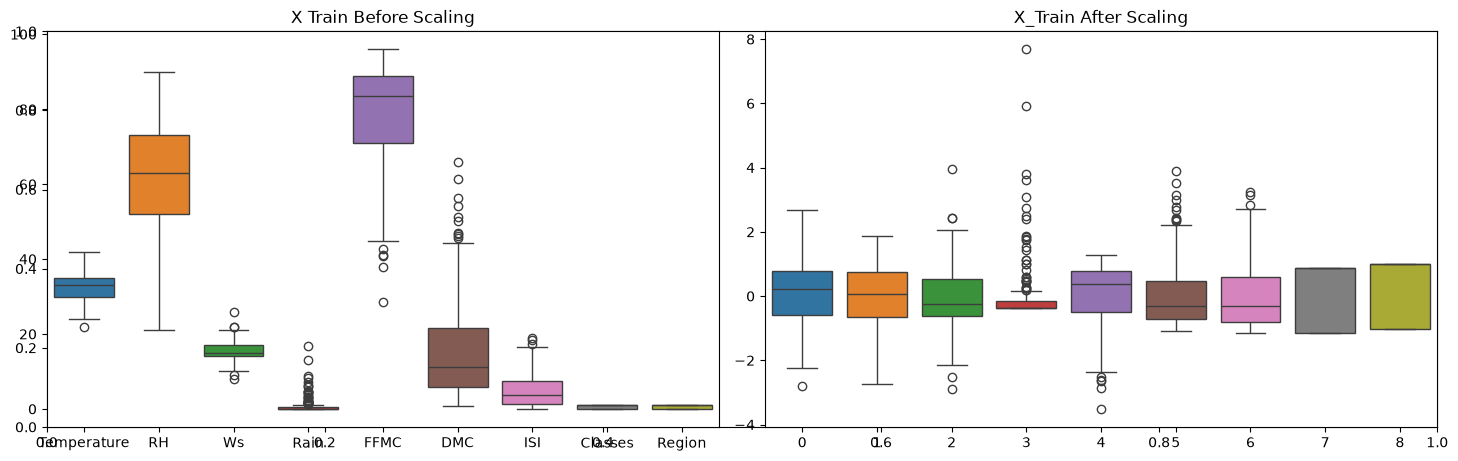

In [23]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title("X Train Before Scaling") 
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("X_Train After Scaling")
plt.tight_layout()

MSE: 0.5049978694165659
r2 score: 0.9805895859259883


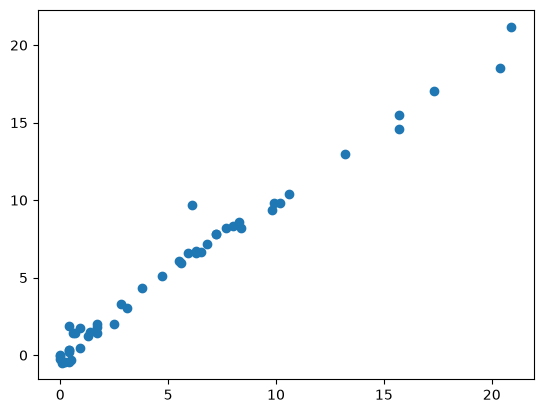

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred = linreg.predict(X_test_scaled)

print(f'MSE: {mean_absolute_error(y_test, y_pred)}')
print(f'r2 score: {r2_score(y_test, y_pred)}')

plt.scatter(y_test, y_pred)

MAE: 1.0093958923873405
r2 Score: 0.9430507350726564


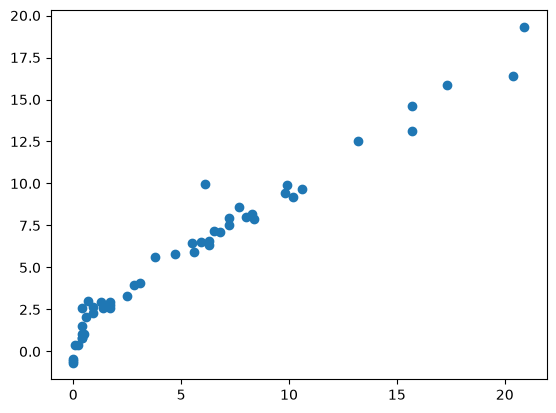

In [25]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print(f'MAE: {mae}')
print(f'r2 Score: {score}')

plt.scatter(y_test, y_pred)

## Cross Validation Lasso

In [26]:
from sklearn.linear_model import LassoCV

lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled, y_train)


,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"alphas alphas: array-like or int, default=100Values of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as an argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, `X` will be copied; otherwise, it may be overwritten.",True
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"positive positive: bool, default=FalseIf positive, restrict regression coefficients to be positive.",False


MAE: 0.5619043833707776
r2 Score: 0.9779732988774219


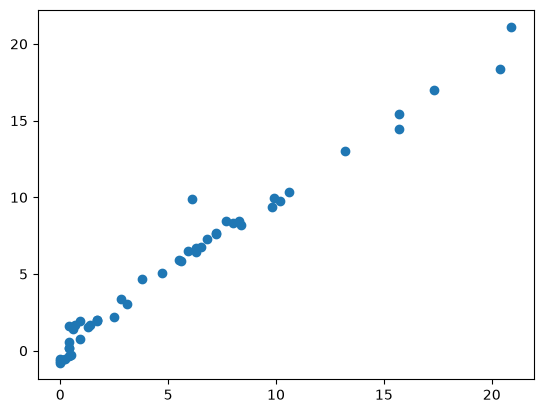

In [27]:
y_pred = lassocv.predict(X_test_scaled)
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f'r2 Score: {r2_score(y_test, y_pred)}')

plt.scatter(y_test, y_pred)

In [28]:
lassocv.get_params()

{'alphas': 100,
 'copy_X': True,
 'cv': 5,
 'eps': 0.001,
 'fit_intercept': True,
 'max_iter': 1000,
 'n_jobs': None,
 'positive': False,
 'precompute': 'auto',
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'verbose': False}

## Ridge Regression Model

MAE: 0.5192048325844796
R2 Score: 0.9801058063273599


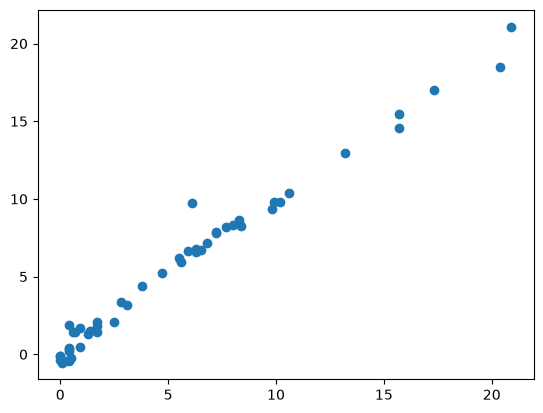

In [29]:
from sklearn.linear_model import Ridge

ridge = Ridge().fit(X_train_scaled, y_train)

y_pred = ridge.predict(X_test_scaled)

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'R2 Score: {r2_score(y_test, y_pred)}')


plt.scatter(y_test, y_pred)

MAE: 0.6869262008277156
R2 Score: 0.9722193780965623


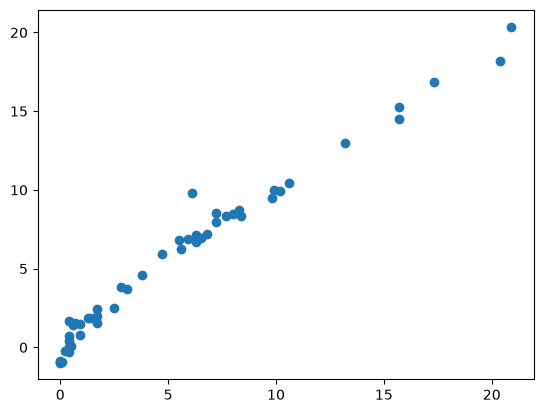

In [30]:
from sklearn.linear_model import RidgeCV

ridgecv = RidgeCV(cv=5).fit(X_train_scaled, y_train)
y_pred = ridgecv.predict(X_test_scaled)
plt.scatter(y_test, y_pred)

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')

print(f"R2 Score: {r2_score(y_test, y_pred)}")

In [31]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

## Elasticnet Regression

MAE: 1.6834416340136709
r2 score: 0.8676961352267807


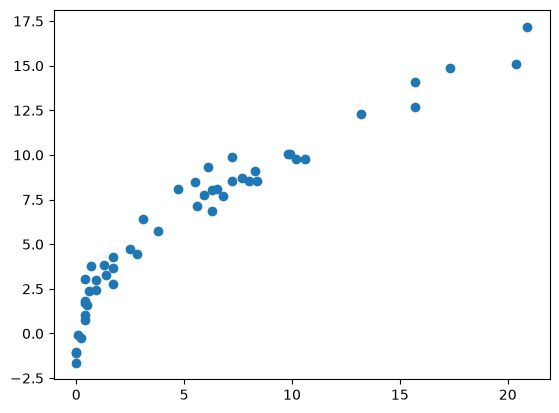

In [32]:
from sklearn.linear_model import ElasticNet
elastic = ElasticNet().fit(X_train_scaled, y_train)
y_pred = elastic.predict(X_test_scaled)

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'r2 score: {r2_score(y_test, y_pred)}')
plt.scatter(y_test, y_pred)

MAE: 0.5710147088777221
r2 score: 0.9781014571778188


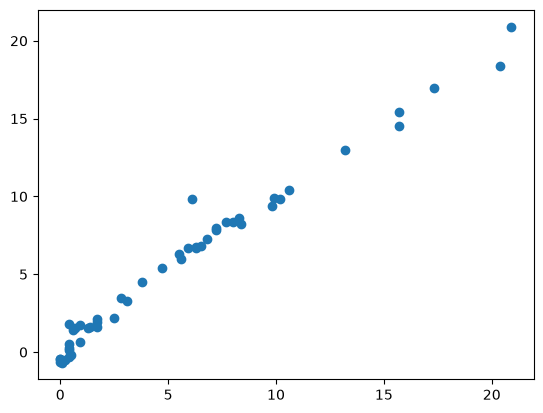

In [33]:
from sklearn.linear_model import ElasticNetCV

elasticCV = ElasticNetCV(cv=5).fit(X_train_scaled, y_train)
y_pred = elasticCV.predict(X_test_scaled)

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'r2 score: {r2_score(y_test, y_pred)}')
plt.scatter(y_test, y_pred)

In [34]:
elasticCV.get_params()

{'alphas': 100,
 'copy_X': True,
 'cv': 5,
 'eps': 0.001,
 'fit_intercept': True,
 'l1_ratio': 0.5,
 'max_iter': 1000,
 'n_jobs': None,
 'positive': False,
 'precompute': 'auto',
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'verbose': 0}

In [35]:
# Pickle the machine Learning models, preprocessing model standardscaler
linreg

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-0.03,-0.18,-0.01,..., 4.89, 0.39,-0.4 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.42
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[29.65,15.39,14.11,..., 7.97, 5.89, 4.65]"


In [36]:
scaler

StandardScaler()

In [37]:
import pickle

pickle.dump(scaler, open('models/scaler.pkl', 'wb'))
pickle.dump(linreg, open('models/linreg.pkl', 'wb'))

FileNotFoundError: [Errno 2] No such file or directory: 'models/scaler.pkl'